In [13]:
import fiftyone as fo
import fiftyone.brain as fob
import fiftyone.zoo as foz

fob.brain_config.default_visualization_method = "umap"

In [14]:
#fob.compute_hardness(samples, label_field, hardness_field='hardness', progress=None)

In [15]:


if fo.dataset_exists("quickstart"):
    fo.delete_dataset("quickstart")

dataset = foz.load_zoo_dataset("quickstart")
dataset_cifar = foz.load_zoo_dataset("cifar10", split="test")

Dataset already downloaded
Loading 'quickstart'
 100% |█████████████████| 200/200 [6.4s elapsed, 0s remaining, 28.2 samples/s]      
Dataset 'quickstart' created


100%|███████████████████████████████████████████████████████████████████████████████| 170M/170M [00:44<00:00, 3.81MB/s]


 100% |█████████████| 10000/10000 [15.9s elapsed, 0s remaining, 681.3 samples/s]      
Dataset info written to 'C:\Users\Hp\fiftyone\cifar10\info.json'
Loading 'cifar10' split 'test'
 100% |█████████████| 10000/10000 [10.7s elapsed, 0s remaining, 919.8 samples/s]      
Dataset 'cifar10-test' created


In [ ]:
"""
Visualization training
"""

In [ ]:
# Generate a visualization with a spatial index
results = fob.compute_visualization(
    dataset,
    brain_key="img_viz",
    create_index=True,
)


In [ ]:
"""
Sort by Similarity
"""

In [4]:


# Index ground truth objects by similarity
fob.compute_similarity(
    dataset,
    patches_field="ground_truth",
    model="clip-vit-base32-torch",
    brain_key="gt_sim",)

fob.compute_similarity(
    dataset,
    model="clip-vit-base32-torch",
    brain_key="img_sim",
)




Computing patch embeddings...
 100% |█████████████████| 200/200 [3.0m elapsed, 0s remaining, 0.7 samples/s]    
Computing embeddings...
 100% |█████████████████| 200/200 [31.6s elapsed, 0s remaining, 6.6 samples/s]      


In [16]:
fob.compute_representativeness(dataset_cifar)

Computing embeddings...
 100% |█████████████| 10000/10000 [4.6m elapsed, 0s remaining, 36.4 samples/s]      
Computing representativeness...
Computing clusters for 10000 embeddings; this may take awhile...
Representativeness computation complete


In [7]:
print(results.has_spatial_index)
# True/False

# Add a spatial index to existing visualization results
results.index_points()

# Remove the spatial index from existing visualization results
results.remove_index()

NameError: name 'results' is not defined

In [17]:
session = fo.launch_app(dataset_cifar)
session.wait()

Notebook sessions cannot wait



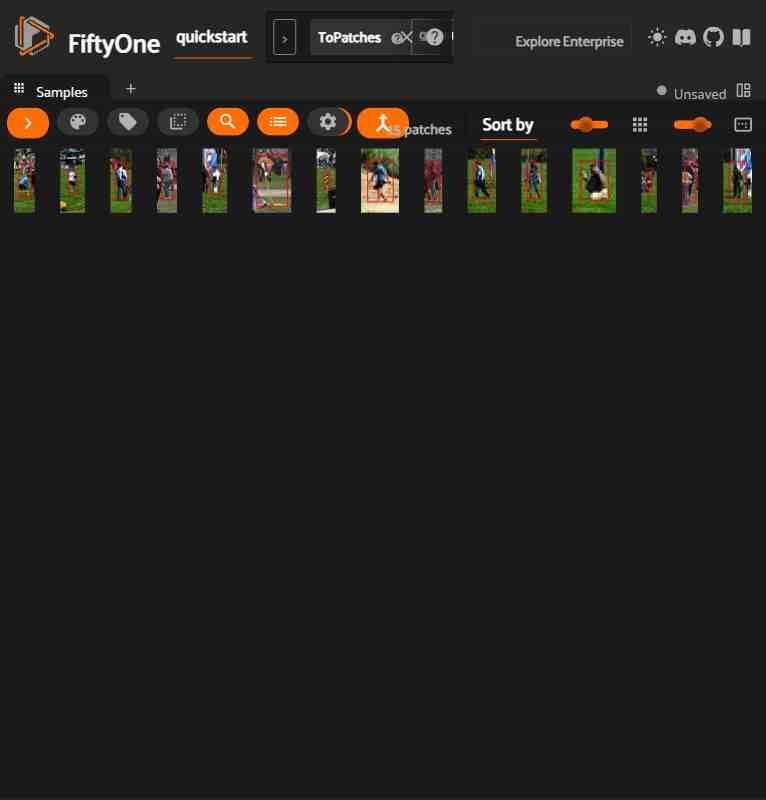


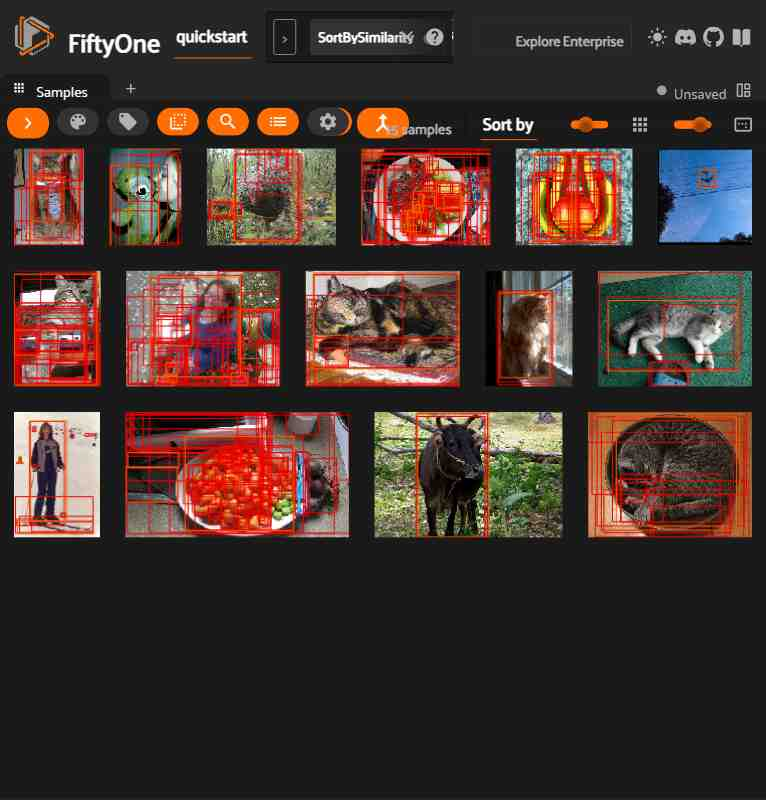

In [8]:
 #Convert to patches view
patches = dataset.to_patches("ground_truth")

# Choose a random patch object from the dataset
query_id = patches.take(1).first().id

# Programmatically construct a view containing the 15 most similar objects
view = patches.sort_by_similarity(query_id, k=15, brain_key="gt_sim")

session.view = view

view_cat = dataset.sort_by_similarity(query="a woman", k=15, brain_key="img_sim")
session.view = view_cat

In [1]:
!git init

Initialized empty Git repository in C:/Users/Hp/OneDrive/Documents/GIG/Research Assistant NST/fiftyone project/.git/


In [2]:
!git status

On branch master

No commits yet

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	.ipynb_checkpoints/
	Untitled.ipynb
	fiftyone_embedding.ipynb
	fiftyoneproject/

nothing added to commit but untracked files present (use "git add" to track)


In [3]:
!git add .

error: 'fiftyoneproject/' does not have a commit checked out
fatal: adding files failed


In [4]:
!git add -A

error: 'fiftyoneproject/' does not have a commit checked out
fatal: adding files failed


In [5]:
!git commit -m "feat: adding fiftyone embedding project"

On branch master

Initial commit

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	.ipynb_checkpoints/
	Untitled.ipynb
	fiftyone_embedding.ipynb
	fiftyoneproject/

nothing added to commit but untracked files present (use "git add" to track)


In [6]:
!git add .

error: 'fiftyoneproject/' does not have a commit checked out
fatal: adding files failed


In [7]:
!git submodule update --init --recursive fiftyoneproject

error: pathspec 'fiftyoneproject' did not match any file(s) known to git


In [8]:
!git rm -r --cached .ipynb_checkpoints 2> NUL

In [9]:
!printf ".ipynb_checkpoints/\n" >> .gitignore

'printf' is not recognized as an internal or external command,
operable program or batch file.


In [10]:
!git add .gitignore

In [11]:
!git commit -m "Ignore Jupyter checkpoints"

[master (root-commit) 1c3299b] Ignore Jupyter checkpoints
 1 file changed, 0 insertions(+), 0 deletions(-)
 create mode 100644 .gitignore


In [12]:
!git status

On branch master
Untracked files:
  (use "git add <file>..." to include in what will be committed)
	.ipynb_checkpoints/
	Untitled.ipynb
	fiftyone_embedding.ipynb
	fiftyoneproject/

nothing added to commit but untracked files present (use "git add" to track)


In [13]:
!git add fiftyone_embedding.ipynb

In [14]:
!git push

fatal: No configured push destination.
Either specify the URL from the command-line or configure a remote repository using

    git remote add <name> <url>

and then push using the remote name

    git push <name>

